In [32]:
!pip install networkx
!pip install matplotlib
!pip install names

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.1/789.1 kB 346.8 kB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for names: filename=names-0.3.0-py3-none-any.whl size=803681 sha256=90837a6cb93319173fcbfe7132db3f582743bb1bc8530e3c0a05bf2a18b50f21
  Stored in directory: /home/jovyan/.cache/pip/wheels/8d/db/fc/50ec19a89a8dcbbd158a4aae44123cb525cda1f07dae287197
Successfully built names


In [1]:
import uuid
from dataclasses import asdict
from itertools import cycle, islice
from random import randint, uniform
from typing import Tuple, List

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from networkx import Graph

from classes import Population, Individual
from utils import read_populations, read_playbooks, transform_number_of_nodes, flatten, print_nodes

from main import *

[
  {
    "status": "Pariah",
    "amount": 1,
    "color": "grey",
    "connection_number": [
      1,
      1
    ]
  },
  {
    "status": "Plebeian",
    "amount": 0,
    "color": "greenyellow",
    "connection_number": [
      2,
      2
    ]
  }
]
Individual(status='Pariah', color='grey', id='843d034c13394583a83ef57dd1d70463', name='William Devore', connections=['55eb7af7da1c4c659c3c46d7d80ed178'])
Individual(status='Plebeian', color='greenyellow', id='127c0644664d40509d24a94db30c9761', name='Charles Winn', connections=['77a79bfad7c84c7f98068ff260405ce4', 'bec04801f3d94b98998de95a6e7f22d0'])
Individual(status='Plebeian', color='greenyellow', id='77a79bfad7c84c7f98068ff260405ce4', name='Sarah Sanchez', connections=['57685879aa6a4d459d68c187a09fc705', '7537760451414cda93547f3211a97636'])
Individual(status='Plebeian', color='greenyellow', id='bec04801f3d94b98998de95a6e7f22d0', name='Gene Dinsmore', connections=['9fb90c5b84ed4f8db128c4a844226e78', '9e0f667282b8484b938a9c222a24c613'])

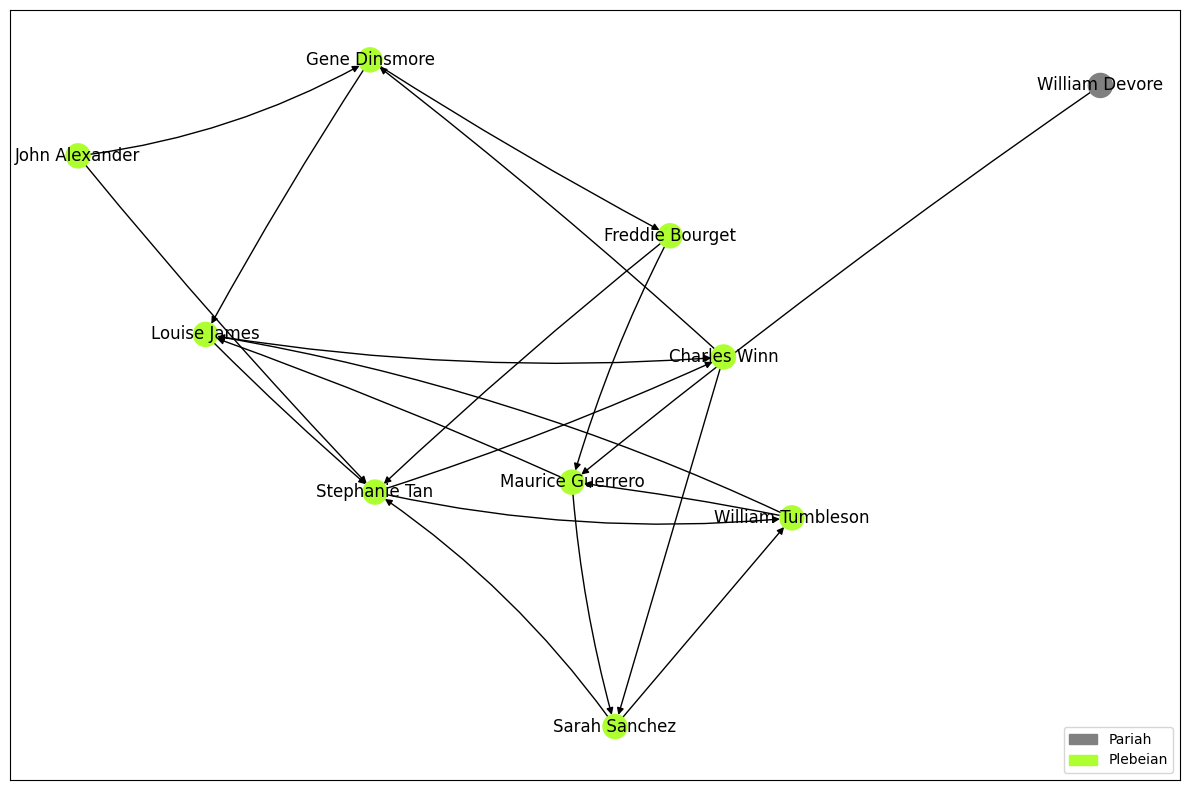

In [4]:
population_list = read_populations(
    schema_file="../schema.json",
    population_file="../populations_basic.json"
)

playbooks = read_playbooks(playbook_file="../playbooks.json")
number_of_nodes = 10
nodes = generate_nodes(number_of_nodes, population_list, playbooks)
connected_nodes = generate_connections(nodes, population_list)

empty_G = nx.MultiDiGraph()
G_nodes = populate_nodes(empty_G, nodes)
G_full = populate_edges(G_nodes, connected_nodes)

edge_number = sum(map(lambda node: len(node.connections), connected_nodes))

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_full, scale=100, iterations=200)
labels = {node.name: node.name for node in nodes}
nx.draw_networkx_labels(G_full, pos, labels=labels)
colors: tuple = tuple(color(el.status, population_list) for el in nodes)
nx.draw_networkx_nodes(G_full, pos, node_color=colors)
for node in connected_nodes:
    print(node)
for edge in G_full.edges:
    style = f'arc3,rad={round(uniform(0., .1), 2)}'
    local_G = empty_G.copy()
    local_G.add_edge(edge[0], edge[1])
    nx.draw_networkx_edges(local_G, pos=pos, arrowsize=10, connectionstyle=style)

unique_statuses = set(el.status for el in nodes)
legend_handles = []
for status in unique_statuses:
    patch = mpatches.Patch(color=color(status, population_list), label=str(status))
    legend_handles.append(patch)

plt.legend(handles=legend_handles, loc="lower right")#, bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()